1\. Environment Setup
---------------------

The authors utilized a Linux-based server with NVIDIA RTX GPUs. For this replication, we use **Detectron2**, a standard library for object detection research.

**Kaggle Note:** We install Detectron2 from source to ensure compatibility with Kaggle's pre-installed PyTorch version. We also ensure pyyaml is pinned to prevent dependency conflicts.

In [1]:
# Installation (Uncomment if needed)
# !pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu111/torch1.9/index.html

!pip install git+https://github.com/facebookresearch/detectron2.git

import os
import copy
import torch
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image

# Detectron2 imports
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, default_setup
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_train_loader
from detectron2.data import transforms as T
from detectron2.data import detection_utils as utils
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.structures import BoxMode

# Define Output Directory for Kaggle (Writable path)
OUTPUT_DIR = "/kaggle/working/output/naive_ddl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Using Torch version: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-q9nqhomj
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-q9nqhomj
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.0 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=6733223 sha256=4bbd901b52c9ec5aaebf4ede6294815368ac7286595b1f89817e1268534d1a9b
  Stored in directory: /tmp/pip-ephem-wheel-cache-7gfe9g0o/wheels/d3/6e/bd/1969578f1456a6be2d6f083da65c669f450b23b8f3d1ac14c1
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=642f0f1949066a88f7e6129ed

2\. Dataset Registration
------------------------

As per **Section 3.1**, the dataset consists of 5,900 images of paprika plants. We follow the paper's split:

*   **70% Training**
    
*   **10% Validation**
    
*   **20% Testing**
    

The DDL unit focuses on 6 abnormality categories found in the Paprika dataset.

In [2]:
# 6 Classes from the dataset README
# Note: Ensure this order matches the ID (0-5) in the YOLO .txt files.
# Usually YOLO starts at 0. Check your _classes.txt if avail.
CLASS_NAMES = [
    "blossom_end_rot",
    "graymold",
    "powdery_mildew",
    "spider_mite",
    "spotting_disease",
    "snails_and_slugs"
]

# === ADJUST THIS PATH ===
# Based on your screenshot, it is likely:
# /kaggle/input/paprika-dataset/data
# OR /kaggle/input/{your-dataset-name}/data
DATASET_ROOT = "/kaggle/input/datasets/tijesu26/paprika-dataset/data" 

def get_paprika_dicts(img_dir, label_dir):
    """
    Parses YOLO format dataset for Detectron2.
    """
    dataset_dicts = []
    # Find all images (support jpg and png)
    image_files = glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png"))
    
    print(f"Found {len(image_files)} images in {img_dir}")
    
    for idx, img_path in enumerate(image_files):
        record = {}
        
        # 1. Get Image Dimensions (Needed for YOLO relative -> absolute conversion)
        # We use PIL to lazy load just the size (faster than reading full image)
        with Image.open(img_path) as img:
            width, height = img.size
            
        record["file_name"] = img_path
        record["image_id"] = idx
        record["height"] = height
        record["width"] = width
        
        # 2. Find Corresponding Label File
        # YOLO structure: images/file.jpg -> labels/file.txt
        filename = os.path.basename(img_path)
        label_filename = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(label_dir, label_filename)
        
        objs = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5: continue
                
                # YOLO: class_id, center_x, center_y, width, height (Normalized)
                class_id = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                
                # Conversion to Absolute XYXY
                abs_cx = cx * width
                abs_cy = cy * height
                abs_w = w * width
                abs_h = h * height
                
                x_min = abs_cx - (abs_w / 2)
                y_min = abs_cy - (abs_h / 2)
                x_max = abs_cx + (abs_w / 2)
                y_max = abs_cy + (abs_h / 2)
                
                obj = {
                    "bbox": [x_min, y_min, x_max, y_max],
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "category_id": class_id,
                }
                objs.append(obj)
        
        record["annotations"] = objs
        dataset_dicts.append(record)
        
    return dataset_dicts

def register_paprika_datasets():
    # Register Train and Valid based on folder structure
    splits = ["train", "valid"]
    
    for split in splits:
        name = f"paprika_{split}"
        img_dir = os.path.join(DATASET_ROOT, split, "images")
        label_dir = os.path.join(DATASET_ROOT, split, "labels")
        
        # Only register if path exists
        if os.path.exists(img_dir):
            DatasetCatalog.register(name, lambda d=img_dir, l=label_dir: get_paprika_dicts(d, l))
            MetadataCatalog.get(name).set(thing_classes=CLASS_NAMES)
            print(f"Successfully Registered: {name}")
        else:
            print(f"Warning: Directory not found: {img_dir}")

# Clear previous registrations if re-running
DatasetCatalog.clear()
register_paprika_datasets()

Successfully Registered: paprika_train
Successfully Registered: paprika_valid


Found 10342 images in /kaggle/input/datasets/tijesu26/paprika-dataset/data/train/images


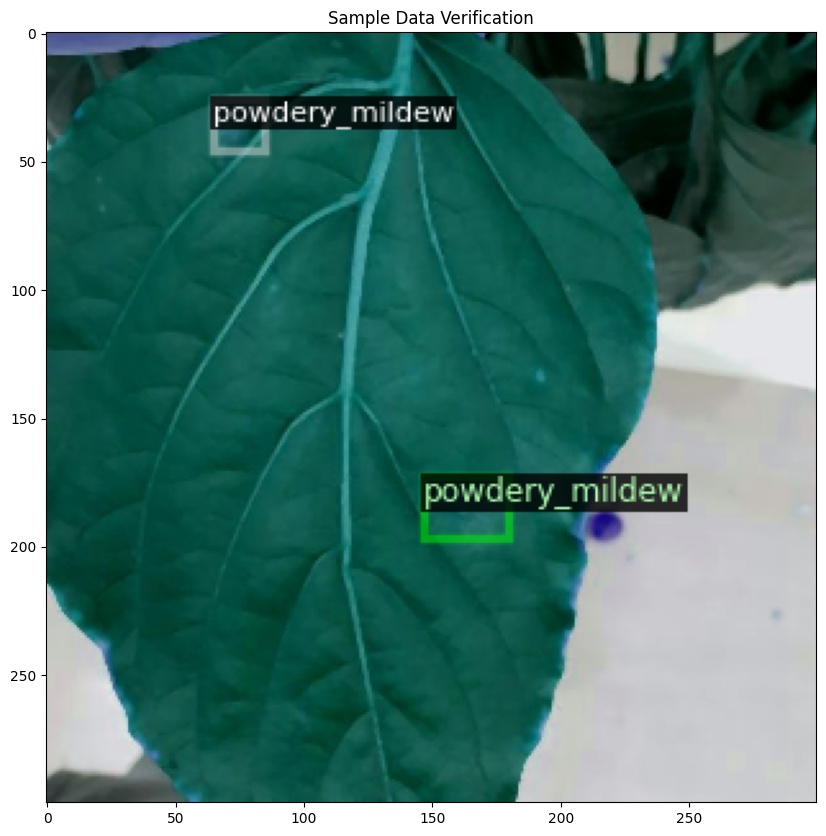

In [3]:
# Verification
if "paprika_train" in DatasetCatalog.list():
    dataset_dicts = DatasetCatalog.get("paprika_train")
    if len(dataset_dicts) > 0:
        d = dataset_dicts[20]
        img = utils.read_image(d["file_name"], format="BGR")
        visualizer = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("paprika_train"), scale=0.5)
                
        # === REDUCE TEXT SIZE ===
        # Manually override the calculated font size
        # Try values between 10 (small) and 25 (large)
        # visualizer._default_font_size = 15
        
        out = visualizer.draw_dataset_dict(d)
        plt.figure(figsize=(10, 10))
        plt.imshow(out.get_image()[:, :, ::-1])
        plt.title("Sample Data Verification")
        plt.show()
    else:
        print("Dataset registered but no images found.")

## 3. Augmentation Strategy

We implement the specific augmentations mentioned in **Table 4** of the paper.
The authors noted that *Color Temperature* and *Noise* reduced performance, while *Geometric* transforms improved it.

**Implemented Transforms:**
1.  **Random Flip:** Probability 0.9 (Horizontal).
2.  **Scale/Resize:** Table 4 lists `Scale x=[0.8, 1.2]`. In Detectron2, we implement this via `ResizeShortestEdge` with a range of sizes to simulate multi-scale training around the 1024px baseline.


In [4]:
def custom_mapper(dataset_dict):
    """
    Custom mapper to implement Table 4 augmentations.
    """
    dataset_dict = copy.deepcopy(dataset_dict)
    
    # Read image
    image = utils.read_image(dataset_dict["file_name"], format="BGR")
    
    # Baseline input size from Table 5 is 1024x1024
    # We create a range [0.8 * 1024, 1.2 * 1024] -> [819, 1228]
    min_size_range = (820, 1220) 
    
    transform_list = [
        # Table 4: Random Flip (prob=0.9)
        T.RandomFlip(prob=0.9, horizontal=True, vertical=False),
        
        # Table 4: Scale [0.8, 1.2]
        # We sample the shortest edge from the range to achieve scaling
        T.ResizeShortestEdge(short_edge_length=min_size_range, max_size=1333, sample_style='range'),
    ]
    
    image, transforms = T.apply_transform_gens(transform_list, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))

    # Apply transforms to annotations (bounding boxes)
    if "annotations" in dataset_dict:
        annos = [
            utils.transform_instance_annotations(obj, transforms, image.shape[:2])
            for obj in dataset_dict.pop("annotations")
            if obj.get("iscrowd", 0) == 0
        ]
        instances = utils.annotations_to_instances(annos, image.shape[:2])
        dataset_dict["instances"] = utils.filter_empty_instances(instances)
    
    return dataset_dict

### 3.1 Custom Trainer Definition

# We subclass `DefaultTrainer` to hook in our `custom_mapper`.

class NaiveDDLTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        # Swap standard loader for our custom mapper
        return build_detection_train_loader(cfg, mapper=custom_mapper)

## 4. Model Configuration (Naïve DDL)
  - **Optimizer:** SGD
  - **Momentum:** 0.9
  - **Base LR:** 0.08 (with Cosine Decay)
  - **Weight Decay:** 0.0005
  - **Batch Size:** 16
  - **Max Iterations:** 100,000

<!-- end list -->

In [5]:
def setup_cfg():
    cfg = get_cfg()
    
    # 1. Architecture: Faster R-CNN R50 FPN (Matches Table 5 Naive Framework)
    cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
    
    # 2. Dataset Registry (Updated to match the split names we registered)
    cfg.DATASETS.TRAIN = ("paprika_train",)
    cfg.DATASETS.TEST = ("paprika_valid",) # Using 'valid' as test
    cfg.DATALOADER.NUM_WORKERS = 2  
    
    # 3. Solver / Training Config (Table 3)
    # Note: 16 batch size requires high VRAM. On Kaggle P100 (16GB), use 4 or 8.
    # We scale LR accordingly: 0.08 is for batch 16. If batch 4, LR -> 0.02
    cfg.SOLVER.IMS_PER_BATCH = 4        
    cfg.SOLVER.BASE_LR = 0.02           
    
    cfg.SOLVER.MOMENTUM = 0.9
    cfg.SOLVER.WEIGHT_DECAY = 0.0005
    cfg.SOLVER.MAX_ITER = 10000          # Reduced for Kaggle Demo (Paper: 100000)
    cfg.SOLVER.WARMUP_ITERS = 1000      # 0-1K Warmup
    
    # 4. Learning Rate Scheduler
    cfg.SOLVER.LR_SCHEDULER_NAME = "WarmupCosineLR"
    
    # 5. Input Resolution (Table 5: 1024x1024)
    cfg.INPUT.MIN_SIZE_TRAIN = (1024,)
    cfg.INPUT.MAX_SIZE_TRAIN = 1024
    cfg.INPUT.MIN_SIZE_TEST = 1024
    cfg.INPUT.MAX_SIZE_TEST = 1024
    
    # 6. Model Heads
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512 
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 6  # 6 Paprika anomalies
    
    # 7. Output
    cfg.OUTPUT_DIR = OUTPUT_DIR
    
    return cfg

cfg = setup_cfg()

## 5\. Training Loop

We initialize the custom trainer and start the process.

In [6]:
# Initialize the trainer with our custom mapper
trainer = NaiveDDLTrainer(cfg)

# Load ImageNet pretrained weights (standard for D2)
trainer.resume_or_load(resume=False)

# Start Training
print(f"Starting Training: {datetime.now()}")
print(f"Configured for {cfg.SOLVER.MAX_ITER} iterations.")

[02/19 20:03:43 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

R-50.pkl: 102MB [00:00, 128MB/s]                            


[02/19 20:04:03 d2.checkpoint.c2_model_loading]: Renaming Caffe2 weights ......
[02/19 20:04:03 d2.checkpoint.c2_model_loading]: Following weights matched with submodule backbone.bottom_up - Total num: 54


Some model parameters or buffers are not found in the checkpoint:
backbone.fpn_lateral2.{bias, weight}
backbone.fpn_lateral3.{bias, weight}
backbone.fpn_lateral4.{bias, weight}
backbone.fpn_lateral5.{bias, weight}
backbone.fpn_output2.{bias, weight}
backbone.fpn_output3.{bias, weight}
backbone.fpn_output4.{bias, weight}
backbone.fpn_output5.{bias, weight}
proposal_generator.rpn_head.anchor_deltas.{bias, weight}
proposal_generator.rpn_head.conv.{bias, weight}
proposal_generator.rpn_head.objectness_logits.{bias, weight}
roi_heads.box_head.fc1.{bias, weight}
roi_heads.box_head.fc2.{bias, weight}
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
The checkpoint state_dict contains keys that are not used by the model:
  fc1000.{bias, weight}
  stem.conv1.bias


Starting Training: 2026-02-19 20:04:03.686150
Configured for 10000 iterations.


In [7]:
# Uncomment below to run training
trainer.train()

[02/19 20:04:03 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[02/19 20:04:35 d2.utils.events]:  eta: 3:52:17  iter: 19  total_loss: 0.8173  loss_cls: 0.1346  loss_box_reg: 0.008276  loss_rpn_cls: 0.6442  loss_rpn_loc: 0.03342    time: 1.4059  last_time: 1.3605  data_time: 0.0856  last_data_time: 0.0668   lr: 0.00039032  max_mem: 7365M


2026-02-19 20:04:37.805205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771531478.030106      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771531478.094446      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771531478.613960      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771531478.614007      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771531478.614009      24 computation_placer.cc:177] computation placer alr

[02/19 20:05:21 d2.utils.events]:  eta: 4:00:40  iter: 39  total_loss: 0.4663  loss_cls: 0.1355  loss_box_reg: 0.009314  loss_rpn_cls: 0.2789  loss_rpn_loc: 0.02988    time: 1.4320  last_time: 1.5411  data_time: 0.0253  last_data_time: 0.0160   lr: 0.00078013  max_mem: 7365M
[02/19 20:05:52 d2.utils.events]:  eta: 4:03:53  iter: 59  total_loss: 0.3315  loss_cls: 0.1421  loss_box_reg: 0.02801  loss_rpn_cls: 0.1411  loss_rpn_loc: 0.03097    time: 1.4690  last_time: 1.4703  data_time: 0.0518  last_data_time: 0.0259   lr: 0.0011699  max_mem: 7365M
[02/19 20:06:24 d2.utils.events]:  eta: 4:07:40  iter: 79  total_loss: 0.3734  loss_cls: 0.1276  loss_box_reg: 0.0418  loss_rpn_cls: 0.1483  loss_rpn_loc: 0.03901    time: 1.5053  last_time: 1.5548  data_time: 0.0442  last_data_time: 0.0227   lr: 0.0015598  max_mem: 7365M
[02/19 20:06:59 d2.utils.events]:  eta: 4:17:29  iter: 99  total_loss: 0.3376  loss_cls: 0.1271  loss_box_reg: 0.05982  loss_rpn_cls: 0.1067  loss_rpn_loc: 0.02912    time: 1.54